The purpose of this notebook is to detrend wdc06a with linear and 2nd order polynomials, then compare the raw timeseries, variance, and power spectrum

In [1]:
from methane_noise_forcing import io
from hydra import compose, initialize
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from astropy.timeseries import LombScargle

In [3]:
with initialize(
    version_base=None, config_path="../../configs"
):  # configs with data paths
    cfg = compose(config_name="config")

In [4]:
## load data
site_name = "wdc06a"
data = io.load_observational_data(site_name, **cfg.io[site_name].input)

2025-08-14 15:42:19,820 - methane_noise_forcing.io - INFO - Loading WDC06A data from /Users/ericm/Documents/Research/methane_noise_forcing/data/observations/cultivated/mitchelletal2013_wdc06a.csv


In [10]:
plot_kwargs = {
    "marker": "o",
    "markersize": 4,
    "linestyle": "None",
}

Standard deviation of linear detrended data: 14.36 ppb
Standard deviation of 2nd order detrended data: 10.16 ppb


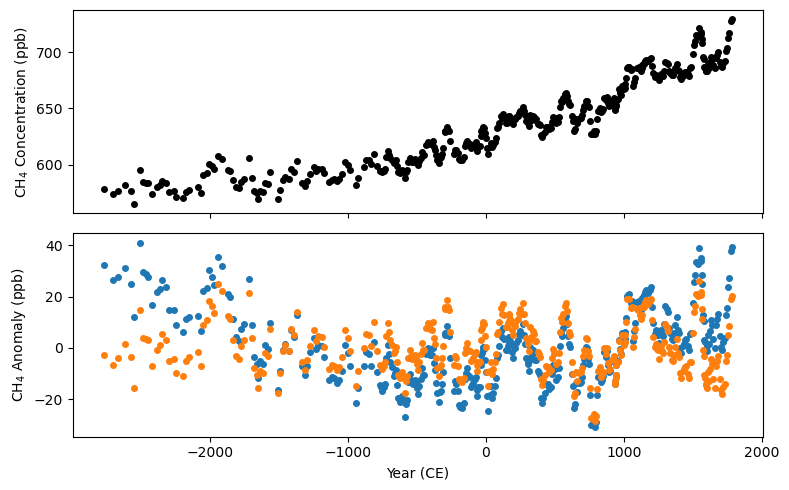

In [26]:
## different detrending methods
# linear
coeffs_linear = np.polyfit(data.gas_age, data.ch4, 1)
data["ch4_linear"] = data.ch4 - np.polyval(coeffs_linear, data.gas_age)

# 2nd order polynomial
coeffs_poly2 = np.polyfit(data.gas_age, data.ch4, 2)
data["ch4_poly2"] = data.ch4 - np.polyval(coeffs_poly2, data.gas_age)

## calculate standard deviation in detrended data
std_linear = np.std(data.ch4_linear, ddof=1)
std_poly2 = np.std(data.ch4_poly2, ddof=1)
print(f"Standard deviation of linear detrended data: {std_linear:.2f} ppb")
print(f"Standard deviation of 2nd order detrended data: {std_poly2:.2f} ppb")

## plot raw and detrended data
fig, axs = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
axs[0].plot(data.gas_age, data.ch4, label="Raw CH4", color="black", **plot_kwargs)
axs[0].set_ylabel("CH$_4$ Concentration (ppb)")

axs[1].plot(
    data.gas_age,
    data.ch4_linear,
    label="Linear Detrended",
    color="tab:blue",
    **plot_kwargs,
)
axs[1].plot(
    data.gas_age,
    data.ch4_poly2,
    label="2nd Order Detrended",
    color="tab:orange",
    **plot_kwargs,
)
axs[1].set_ylabel("CH$_4$ Anomaly (ppb)")
axs[1].set_xlabel("Year (CE)")

plt.tight_layout()

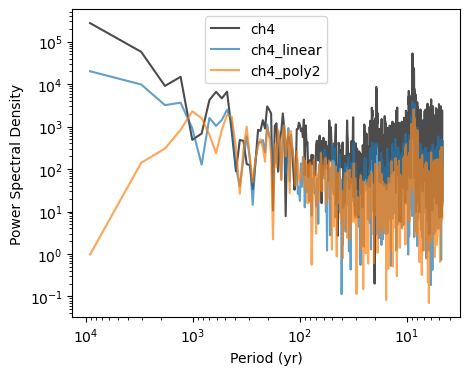

In [31]:
## calculate power spectra
psds = {}
for method in ["ch4", "ch4_linear", "ch4_poly2"]:
    frequency, power = LombScargle(data.gas_age, data[method]).autopower(
        normalization="psd", samples_per_peak=1
    )
    psds[method] = power

# plot power spectra
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
colors = {"ch4": "black", "ch4_linear": "tab:blue", "ch4_poly2": "tab:orange"}
methods_plot = ["ch4", "ch4_linear", "ch4_poly2"]
for method in methods_plot:
    ax.plot(1 / frequency, psds[method], label=method, color=colors[method], alpha=0.7)

ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_xaxis()
ax.set_xlabel("Period (yr)")
ax.set_ylabel("Power Spectral Density")
ax.legend()